# Notebook 2 — Models, Evaluation & Hyperparameter Tuning

**Goal:** Train 3 models, compare them fairly, tune the best one, and save it.

**Run Notebook 1 first** — this notebook loads the data that Notebook 1 saved.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    confusion_matrix, roc_curve, classification_report
)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print('All libraries loaded!')

All libraries loaded!


c:\Users\Radwan\Desktop\radwan\project\churnx\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Load the processed data from Notebook 1 ──────────────────────────────────
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()

X_test  = pd.read_csv('../data/processed/X_test.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'Training: {X_train.shape} | Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean()*100:.1f}%')
print(f'Test churn rate : {y_test.mean()*100:.1f}%')

Training: (8278, 33) | Test: (1409, 33)
Train churn rate: 50.0%
Test churn rate : 26.5%


## 1. Train Three Models

We always start with a **baseline** (Logistic Regression) before trying complex models.  
If a complex model does not beat the baseline by much, it may not be worth the complexity.

In [3]:
# ── Model 1: Logistic Regression (Baseline) ───────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
print('Logistic Regression trained!')

Logistic Regression trained!


In [4]:
# ── Model 2: Random Forest ────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print('Random Forest trained!')

Random Forest trained!


In [5]:
# ── Model 3: XGBoost ──────────────────────────────────────────────────────────
# use_label_encoder=False and device='cpu' avoids gpu_id issues on all XGBoost versions
xgb_model = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    device='cpu'
)
xgb_model.fit(X_train, y_train)
print('XGBoost trained!')

XGBoost trained!


## 2. Evaluate All Three Models

In [6]:
# ── Helper function: calculate all metrics for one model ─────────────────────
def evaluate_model(model, X_test, y_test, model_name):
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_test, y_pred) * 100, 2),
        'F1 Score' : round(f1_score(y_test, y_pred) * 100, 2),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_pred_prob) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall'   : round(recall_score(y_test, y_pred) * 100, 2),
    }

# ── Evaluate all three ────────────────────────────────────────────────────────
results = [
    evaluate_model(lr,        X_test, y_test, 'Logistic Regression'),
    evaluate_model(rf,        X_test, y_test, 'Random Forest'),
    evaluate_model(xgb_model, X_test, y_test, 'XGBoost'),
]

results_df = pd.DataFrame(results).set_index('Model')
print('Model Comparison (higher is better for all metrics):')
results_df

Model Comparison (higher is better for all metrics):


,Accuracy,F1 Score,ROC-AUC,Precision,Recall
Model,,,,,
Logistic Regression,74.17,61.68,84.54,50.87,78.34
Random Forest,76.86,57.11,82.53,56.22,58.02
XGBoost,76.86,57.99,81.51,55.97,60.16


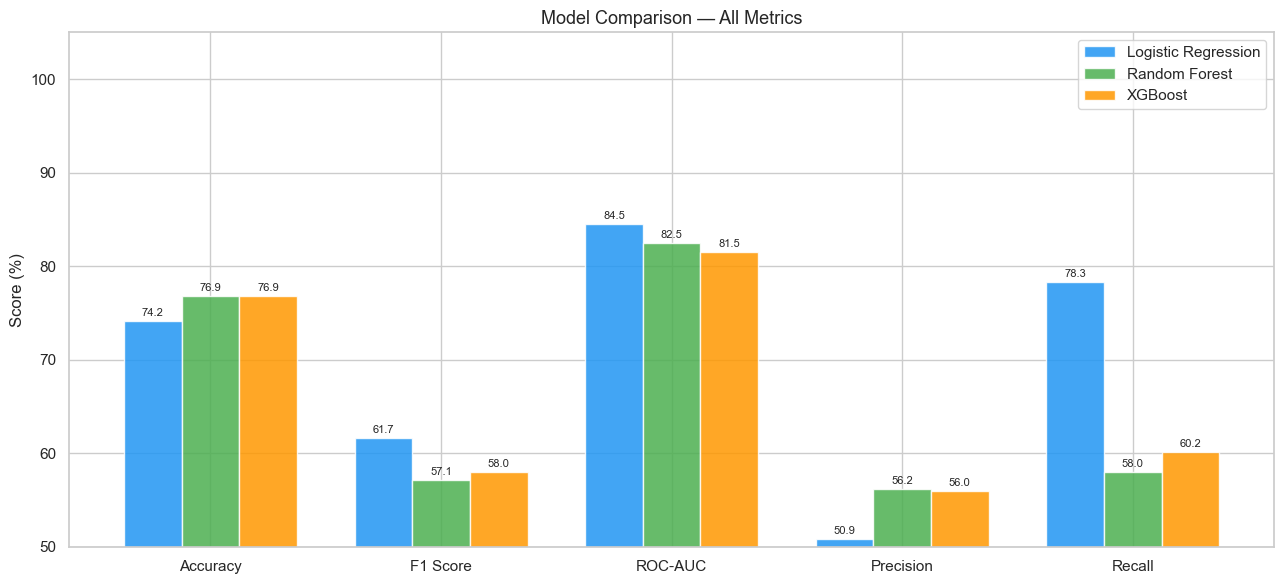

In [7]:
# ── Visualize the comparison ──────────────────────────────────────────────────
metrics   = ['Accuracy', 'F1 Score', 'ROC-AUC', 'Precision', 'Recall']
models_   = results_df.index.tolist()
colors    = ['#2196F3', '#4CAF50', '#FF9800']

x     = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model_name, color) in enumerate(zip(models_, colors)):
    values = results_df.loc[model_name, metrics].values
    bars   = ax.bar(x + i * width, values, width, label=model_name,
                    color=color, edgecolor='white', alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — All Metrics', fontsize=13)
ax.legend()
ax.set_ylim(50, 105)
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Why Not Just Use Accuracy?

> **Exam question:** "Why do you use F1 and ROC-AUC instead of accuracy?"

> **Answer:** Because our dataset is imbalanced. A model that predicts 'no churn' for everyone would get ~73% accuracy but catch zero churners. F1 balances precision and recall. ROC-AUC measures the model's ability to rank churners above non-churners regardless of the threshold.

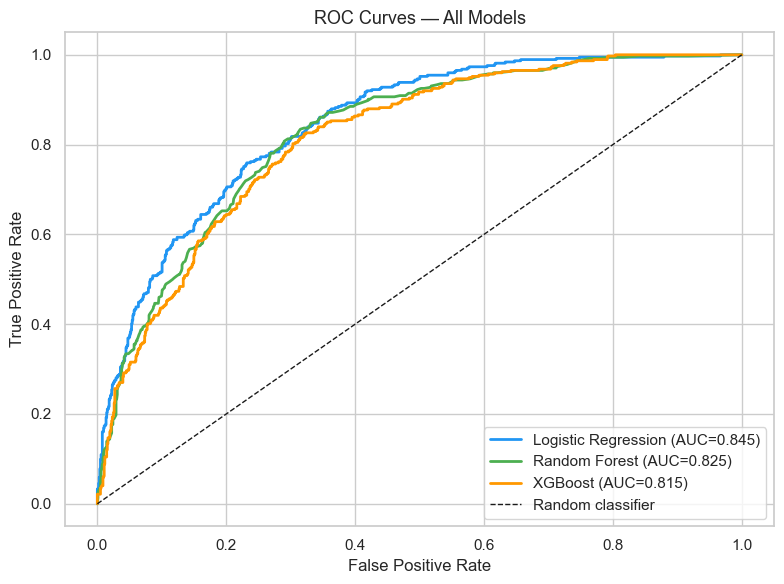

In [8]:
# ── Plot ROC curves for all 3 models ─────────────────────────────────────────
plt.figure(figsize=(8, 6))

for model, name, color in [
    (lr,        'Logistic Regression', '#2196F3'),
    (rf,        'Random Forest',       '#4CAF50'),
    (xgb_model, 'XGBoost',             '#FF9800'),
]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/09_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Cross-Validation — More Reliable Evaluation

Logistic Regression: 0.8561 (+/- 0.0021)
Random Forest: 0.9258 (+/- 0.0042)
XGBoost: 0.9326 (+/- 0.0042)


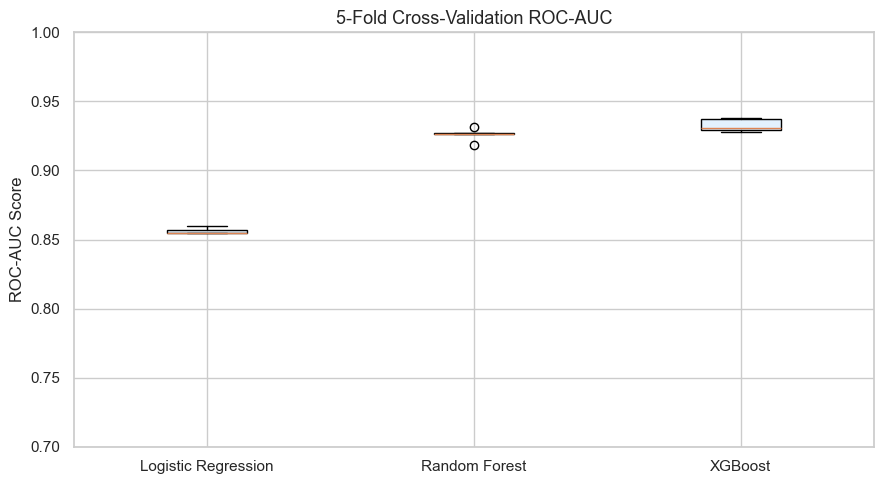

In [9]:
# ── 5-fold cross-validation ───────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for model, name in [
    (lr,        'Logistic Regression'),
    (rf,        'Random Forest'),
    (xgb_model, 'XGBoost'),
]:
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name}: {scores.mean():.4f} (+/- {scores.std():.4f})')

# Boxplot
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor='#E3F2FD'))
ax.set_ylabel('ROC-AUC Score')
ax.set_title('5-Fold Cross-Validation ROC-AUC', fontsize=13)
ax.set_ylim(0.7, 1.0)
plt.tight_layout()
plt.savefig('../reports/figures/10_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Confusion Matrix — See Where Each Model Fails

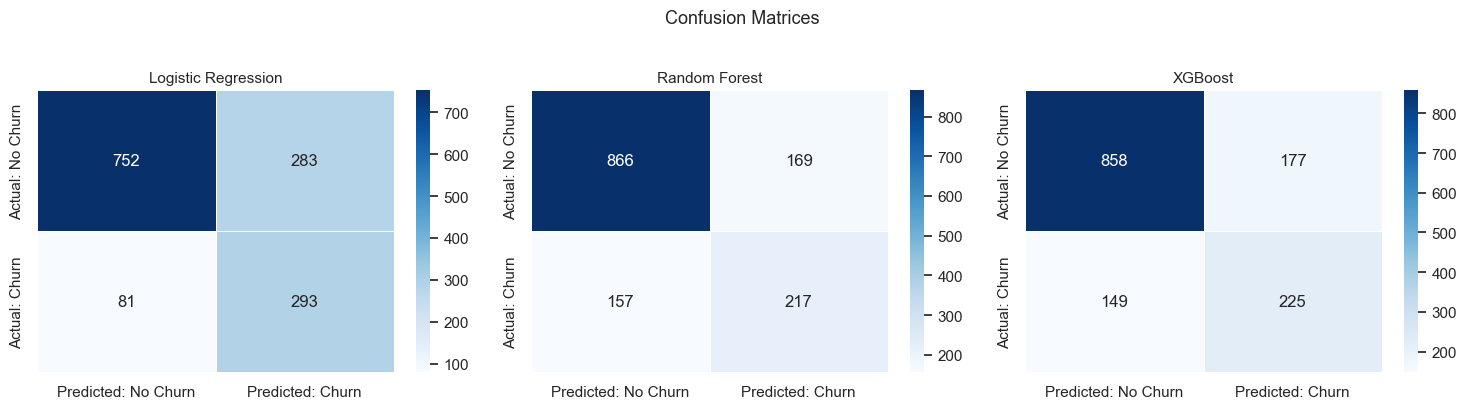

Key insight: For churn, we care more about recall (catching churners) than precision.
Missing a churner costs more than wrongly flagging a loyal customer.


In [10]:
# ── Confusion matrices for all 3 models ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, model, name in zip(axes,
                            [lr, rf, xgb_model],
                            ['Logistic Regression', 'Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Predicted: No Churn', 'Predicted: Churn'],
                yticklabels=['Actual: No Churn', 'Actual: Churn'],
                linewidths=0.5)
    ax.set_title(name, fontsize=11)

plt.suptitle('Confusion Matrices', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/11_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key insight: For churn, we care more about recall (catching churners) than precision.')
print('Missing a churner costs more than wrongly flagging a loyal customer.')

## 6. Hyperparameter Tuning with Optuna

In [11]:
# ── Optuna: automated hyperparameter search ───────────────────────────────────
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'eval_metric'      : 'logloss',
        'random_state'     : 42,
        'verbosity'        : 0,
        'device'           : 'cpu',
    }
    model  = XGBClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=-1)
    return scores.mean()


print('Starting Optuna hyperparameter search (50 trials)...')
print('This will take 3-5 minutes.')

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest ROC-AUC found: {study.best_value:.4f}')
print('Best parameters:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Starting Optuna hyperparameter search (50 trials)...
This will take 3-5 minutes.


Best trial: 25. Best value: 0.937773: 100%|██████████| 50/50 [03:38<00:00,  4.36s/it]


Best ROC-AUC found: 0.9378
Best parameters:
  n_estimators: 151
  max_depth: 9
  learning_rate: 0.06959392666589566
  subsample: 0.6514335127315031
  colsample_bytree: 0.8038451674013002
  min_child_weight: 1


In [12]:
# ── Train the final model with the best parameters ────────────────────────────
best_xgb = XGBClassifier(
    **study.best_params,
    eval_metric='logloss',
    random_state=42,
    verbosity=0,
    device='cpu'
)
best_xgb.fit(X_train, y_train)

before = evaluate_model(xgb_model, X_test, y_test, 'XGBoost (default)')
after  = evaluate_model(best_xgb,  X_test, y_test, 'XGBoost (tuned)')

comparison = pd.DataFrame([before, after]).set_index('Model')
print('Tuning improvement:')
comparison

Tuning improvement:


,Accuracy,F1 Score,ROC-AUC,Precision,Recall
Model,,,,,
XGBoost (default),76.86,57.99,81.51,55.97,60.16
XGBoost (tuned),77.22,57.60,82.54,56.92,58.29


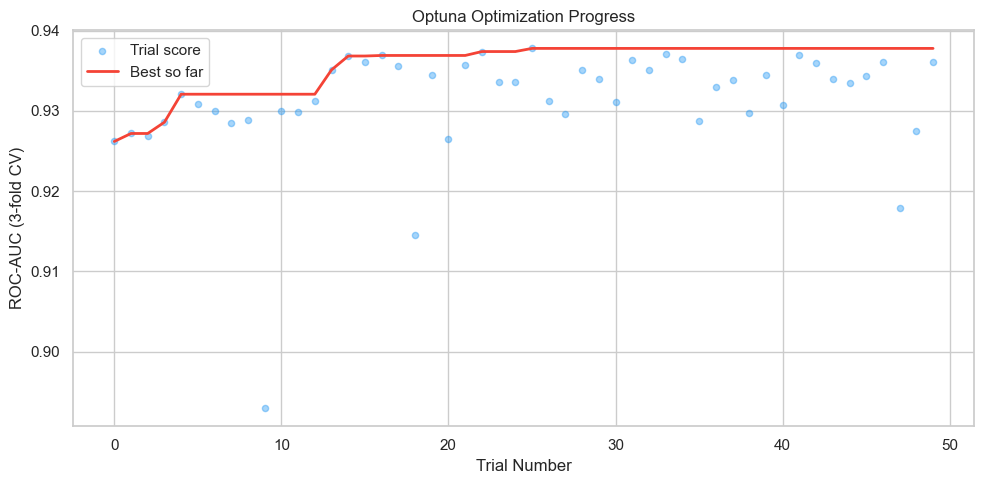

In [13]:
# ── Optuna optimization history chart ────────────────────────────────────────
trial_numbers = [t.number for t in study.trials]
trial_values  = [t.value  for t in study.trials]
best_so_far   = [max(trial_values[:i+1]) for i in range(len(trial_values))]

plt.figure(figsize=(10, 5))
plt.scatter(trial_numbers, trial_values, alpha=0.4, color='#2196F3', s=20, label='Trial score')
plt.plot(trial_numbers, best_so_far, color='#F44336', linewidth=2, label='Best so far')
plt.xlabel('Trial Number')
plt.ylabel('ROC-AUC (3-fold CV)')
plt.title('Optuna Optimization Progress', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/12_optuna_progress.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Full evaluation of the final model ───────────────────────────────────────
y_pred      = best_xgb.predict(X_test)
y_pred_prob = best_xgb.predict_proba(X_test)[:, 1]

print('=== FINAL MODEL: XGBoost (Tuned) ===')
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

=== FINAL MODEL: XGBoost (Tuned) ===

              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.84      1035
       Churn       0.57      0.58      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409



## 7. Decision Document — Why XGBoost Won

| Reason | Evidence |
|--------|----------|
| Highest ROC-AUC | XGBoost > Random Forest > Logistic Regression across all CV folds |
| Highest Recall | Most important metric — catching actual churners is the goal |
| Handles imbalance well | Gradient boosting focuses more on misclassified samples |
| Tunable | Optuna improved it further |
| Works with SHAP | Native SHAP support for fast, exact TreeExplainer values |

## 8. Save the Final Model

In [15]:
# ── Save model using JSON booster format (version-safe) ───────────────────────
# Why JSON? joblib saves the Python object including old XGBoost internal params
# like gpu_id that no longer exist in newer versions — causing crashes.
# Saving via the booster JSON strips those old params and makes it compatible
# with any XGBoost version.

os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# Step 1: save the booster to a clean JSON file
best_xgb.get_booster().save_model('../models/best_model.json')

# Step 2: create a fresh XGBClassifier and load the booster into it
import xgboost as xgboost_lib
fresh_model = xgboost_lib.XGBClassifier(
    eval_metric='logloss',
    verbosity=0,
    device='cpu'
)
fresh_model.load_model('../models/best_model.json')

# Step 3: save the fresh model with joblib — this is what the app loads
joblib.dump(fresh_model, '../models/best_model.joblib')

# Save the results table
all_results = pd.DataFrame([
    evaluate_model(lr,        X_test, y_test, 'Logistic Regression'),
    evaluate_model(rf,        X_test, y_test, 'Random Forest'),
    evaluate_model(xgb_model, X_test, y_test, 'XGBoost (default)'),
    evaluate_model(best_xgb,  X_test, y_test, 'XGBoost (tuned)'),
])
all_results.to_csv('../reports/model_results.csv', index=False)

print('Saved:')
print('  models/best_model.joblib  (version-safe)')
print('  models/best_model.json    (booster backup)')
print('  reports/model_results.csv')
print()
print('Notebook 2 complete! Run Notebook 3 next.')

Saved:
  models/best_model.joblib  (version-safe)
  models/best_model.json    (booster backup)
  reports/model_results.csv

Notebook 2 complete! Run Notebook 3 next.
